In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = os.path.abspath("..")
FIG = os.path.join(BASE, "outputs", "figures")
PROC = os.path.join(BASE, "data", "processed")
RAW = os.path.join(BASE, "data", "raw")
os.makedirs(FIG, exist_ok=True)

print(BASE)
print(os.listdir(PROC))

d = pd.read_csv(os.path.join(PROC, "dhaka_clean.csv"), parse_dates=["datetime"])
print(d.shape)

/mnt/g/dhaka-air-quality-analysis
['dhaka_clean.csv']
(28992, 13)


In [6]:
#cell 2
print("Ozone peak hour:", d.groupby("hour")["ozone"].mean().idxmax())
print("PM2.5 lowest hour:", d.groupby("hour")["pm2_5"].mean().idxmin())

Ozone peak hour: 8
PM2.5 lowest hour: 9


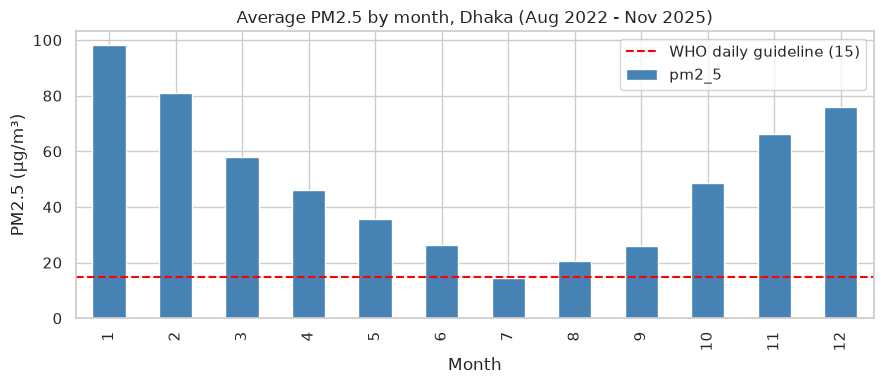

In [7]:
#cell 3
monthly = d.groupby("month")["pm2_5"].mean()
ax = monthly.plot(kind="bar", color="steelblue", figsize=(9, 4))
ax.set_title("Average PM2.5 by month, Dhaka (Aug 2022 - Nov 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.axhline(15, color="red", ls="--", label="WHO daily guideline (15)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "pm25_by_month.png"), dpi=150)
plt.show()